**END-TO-END SALES FORECASTING & DEMAND INTELLIGENCE SYSTEM**

**Data Loading, Merging & Deep Exploration**

In [1]:
# Loading Data

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
# Converting Order Date and Ship Date to Datetime Format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst = True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst = True)

df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [6]:
# Extracting Time Features 

## Year, Month, Week Number, Day of Week, Quarter
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

## Seasons & its Months
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

## Display DataFrame
df[["Year", "Month", "Week Number", "Day of Week", "Quarter", "Season"]].head(4)

,Year,Month,Week Number,Day of Week,Quarter,Season
0,2017,11,45,Wednesday,4,Autumn
1,2017,11,45,Wednesday,4,Autumn
2,2017,6,24,Monday,2,Summer
3,2016,10,41,Tuesday,4,Autumn


In [7]:
# Checking Missing Values, Duplicates, and Datatype Issues
print("Missing Values:", df.isnull().sum())
print("Duplicates rows:", df.duplicated().sum())
print("Data Types:", df.dtypes)

Missing Values: Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64
Duplicates rows: 0
Data Types: Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category    

In [8]:
# Daily Sales Aggregration

## Weekly Sales
weekly_sales = (
    df.groupby(pd.Grouper(key = "Order Date", freq = "W"))["Sales"]
    .sum()
    .reset_index()
)

## Monthly Sales
monthly_sales = (
    df.groupby(pd.Grouper(key = "Order Date", freq = "ME"))["Sales"]
    .sum()
    .reset_index()
)

## Display
print("Weekly Sales:", weekly_sales.head(4))
print("Monthly sales:", monthly_sales.head(4))

Weekly Sales:   Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
Monthly sales:   Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855


In [9]:
# Calculates Sales

## Calculates Sales by Category
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending = False)
)
print(category_sales)
print("-" * 100)

## Region Yearly sales
region_yearly_sales = (
    df.groupby(["Region", "Year"])["Sales"]
    .sum()
    .unstack()
)
print(region_yearly_sales)
print("-" * 100)

## Average Time Between Order Date and Ship date
### Overall Average
df["Shipping Dates"] = (df["Ship Date"] - df["Order Date"]).dt.days
print("Average Shipping Dates:", df["Shipping Dates"].mean())
### Region-Wise Average
shipping_region = (
    df.groupby("Region")["Shipping Dates"]
    .mean()
    .sort_values()
)
print(shipping_region)
print("-" * 100)

## Monthly Consistence
monthly_pattern = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .unstack(0)
)
print(monthly_pattern)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
----------------------------------------------------------------------------------------------------
Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255
----------------------------------------------------------------------------------------------------
Average Shipping Dates: 3.9611224489795918
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Dates, dtype: float64
----------------------------------------------------------------------------------------------------
Year         2015        2016        201

**Time Series Analysis & Decomposition**

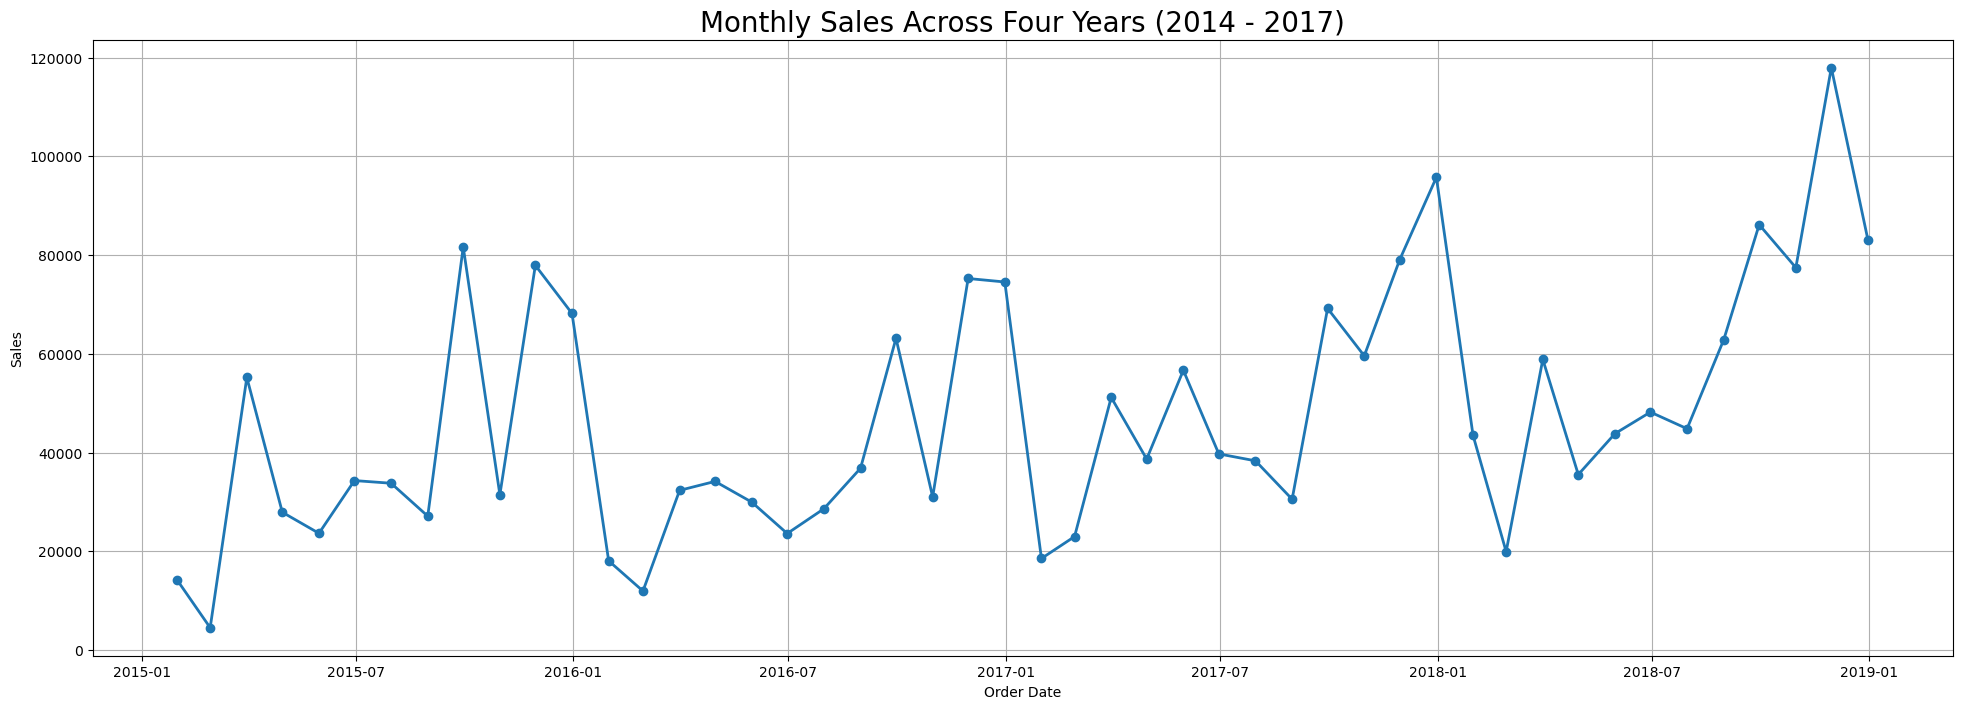

In [10]:
# Monthly Sales Across 4 Years
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 8))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker = "o",
    linewidth = 2
)

plt.title("Monthly Sales Across Four Years (2014 - 2017)", fontsize = 20)
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()


In [11]:
# Applying Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_sales.set_index("Order Date", inplace = True)

decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model = "additive",
    period = 12
)

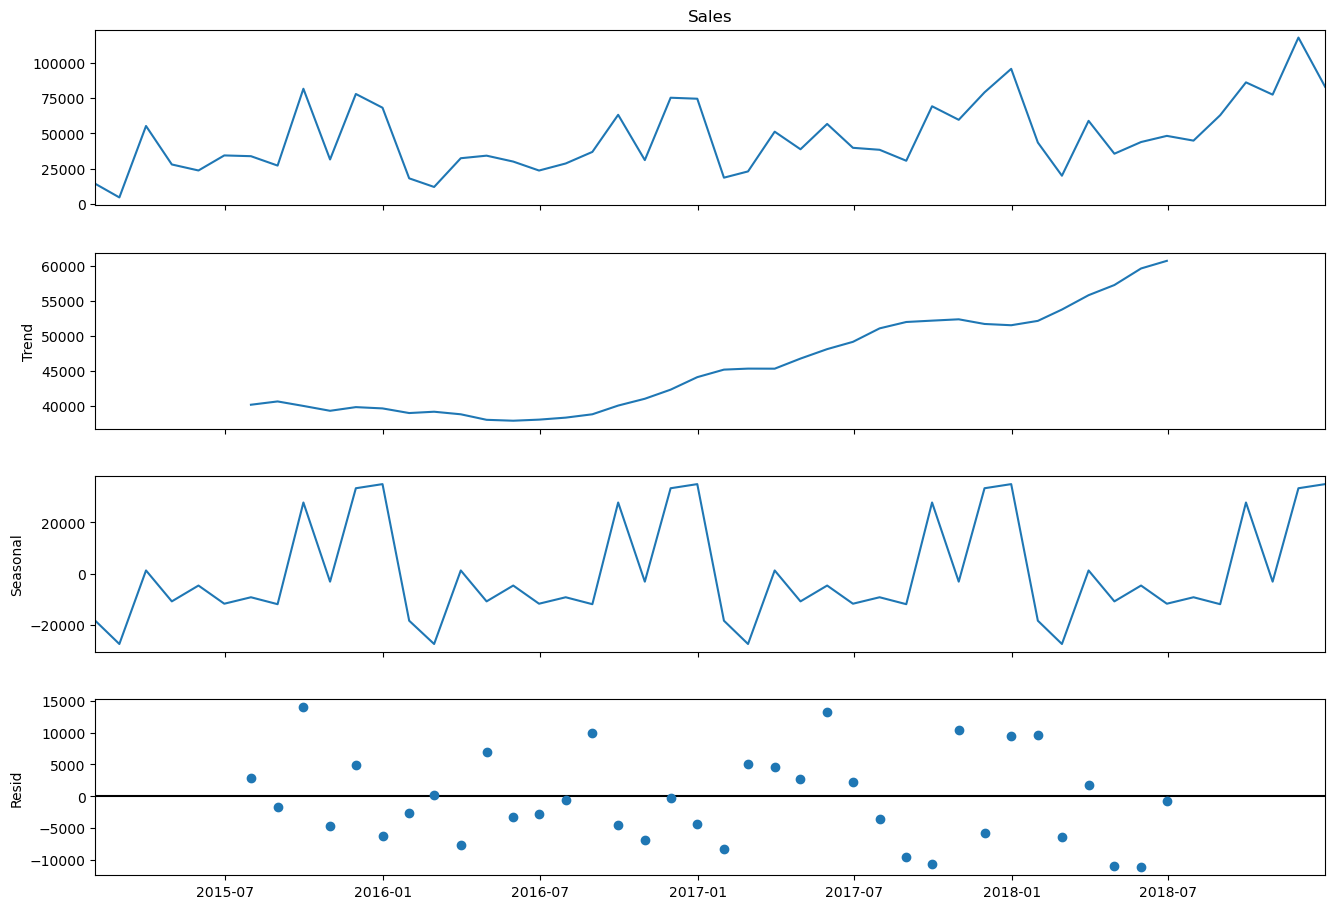

In [12]:
# Plotting All 4 Components
fig = decomposition.plot()
fig.set_size_inches(15, 10)

plt.show()

In [13]:
# Observations of Graphs

## Trend: The trend component shows that overall sales have increased steadily over the four-year period, indicating positive business growth.
## Seasonality: The seasonal component is strong, as the sales pattern repeats every year. Sales are consistently higher during October to December, while February records comparatively lower sales.
## Residual Noise: The residual component represents random fluctuations or unexpected changes in sales that are not explained by the trend or seasonal pattern. Higher residual values indicate unusual sales spikes or drops, which may be caused by factors such as promotions, festivals, discounts, or other unexpected events.

In [14]:
# Checking Stationarity using the Augmented Dickey-Fuller (ADF) Test
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales["Sales"])

print("ADF Statistic  :", adf_result[0])
print("p-Value        :", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

if adf_result[1] < 0.05:
    print("\nThe time series is stationary.")
else:
    print("\nThe time series is non-stationary.")

ADF Statistic  : -4.416136761430769
p-Value        : 0.00027791039276670623
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064

The time series is stationary.


In [15]:
## Stationarity is used to check whether the statistical properties of a time series remain stable over time. It is performed before applying the SARIMA model because SARIMA requires the data to be stationary. If the p-value is greater than 0.05, the data is considered non-stationary, and we need to apply differencing and perform the ADF test again. Once the p-value becomes less than 0.05, the data is considered stationary, indicating a stable pattern that is suitable for the SARIMA model.

**Sales Forecasting using 3 Different Models**

In [16]:
import warnings
warnings.filterwarnings("ignore")

**Model 1 — SARIMA (Statistical Model)**

In [17]:
# Building SARIMA Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

monthly_sales = monthly_sales.asfreq("ME")

sarima_model = SARIMAX(
    monthly_sales["Sales"],
    order = (1,1,1),
    seasonal_order = (1,1,1,12)
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -383.926
Date:                            Sun, 12 Jul 2026   AIC                            777.851
Time:                                    18:54:42   BIC                            785.628
Sample:                                01-31-2015   HQIC                           780.536
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5094      0.234      2.179      0.029       0.051       0.968
ma.L1         -0.9007      0.185   

In [18]:
# The SARIMA model was configured with order (1,1,1) and seasonal order (1,1,1,12). The value of d = 1 was chosen because the original sales data was non-stationary, and first-order differencing was required to make the series stationary. The value of m = 12 was selected because the dataset contains monthly sales, meaning one complete seasonal cycle occurs every 12 months. The values p = 1, q = 1, P = 1, and Q = 1 were chosen as a standard baseline configuration to capture both short-term and yearly seasonal patterns. These parameters can be further optimized using ACF/PACF analysis or by comparing AIC values across different SARIMA models.

In [19]:
# Future Forecast with Confidence Intervals
forecast = sarima_result.get_forecast(steps = 3)

forecast_mean = forecast.predicted_mean

confidence_intervals = forecast.conf_int()

print("3-Months Future Predictions:")
print(forecast_mean)
print("-" * 100)
print("Confidence_Intervals:")
print(confidence_intervals)

3-Months Future Predictions:
2019-01-31    43492.278941
2019-02-28    34805.105223
2019-03-31    69907.412164
Freq: ME, Name: predicted_mean, dtype: float64
----------------------------------------------------------------------------------------------------
Confidence_Intervals:
             lower Sales    upper Sales
2019-01-31  13699.516243   73285.041639
2019-02-28    -81.437548   69691.647994
2019-03-31  32944.417370  106870.406958


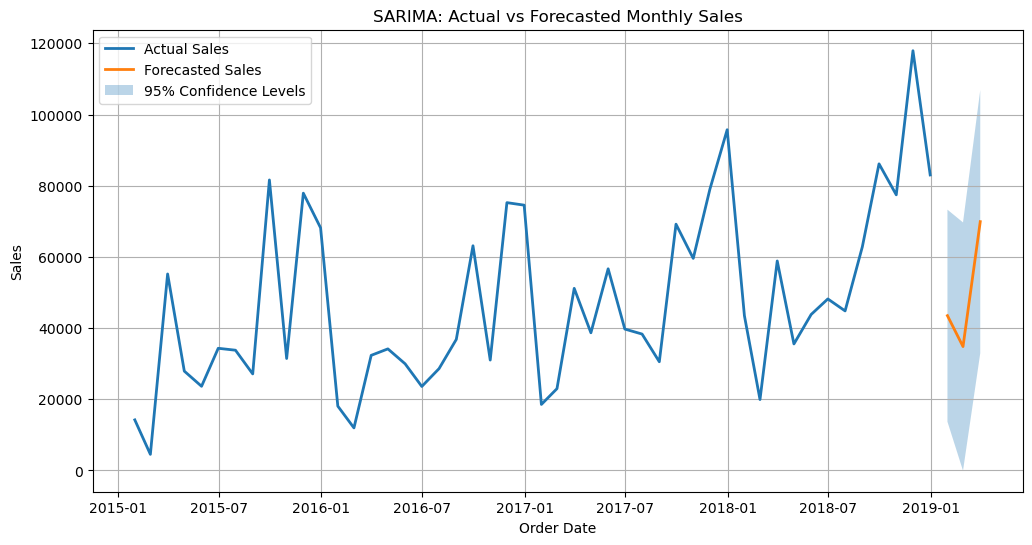

In [20]:
# Plotting Actual VS Forecasted Sales
import matplotlib.pyplot as plt
plt.figure(figsize = (12,6))

## Actual Sales
plt.plot(
    monthly_sales.index,
    monthly_sales["Sales"],
    label = "Actual Sales",
    linewidth = 2
)

## Forecasted Sales
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label = "Forecasted Sales",
    linewidth = 2
)

## Confidence Intervals
plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    alpha = 0.3,
    label = "95% Confidence Levels"
)

## Display chart
plt.title("SARIMA: Actual vs Forecasted Monthly Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Train-Test Split
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_eval = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_eval_result = sarima_eval.fit()

sarima_pred = sarima_eval_result.forecast(steps=3)

print("Actual Sales")
print(test["Sales"])

print("\nPredicted Sales")
print(sarima_pred)

Actual Sales
Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64

Predicted Sales
2018-10-31    66177.602408
2018-11-30    92049.249646
2018-12-31    99965.168678
Freq: ME, Name: predicted_mean, dtype: float64


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
sarima_mae = mean_absolute_error(
    test["Sales"],
    sarima_pred
)

# RMSE
sarima_rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        sarima_pred
    )
)

# MAPE
sarima_mape = np.mean(
    np.abs(
        (
            test["Sales"] - sarima_pred
        ) / test["Sales"]
    )
) * 100

print("SARIMA MAE :", round(sarima_mae,2))
print("SARIMA RMSE:", round(sarima_rmse,2))
print("SARIMA MAPE:", round(sarima_mape,2), "%")

SARIMA MAE : 18031.4
SARIMA RMSE: 19009.18
SARIMA MAPE: 18.97 %


**Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)**

In [23]:
# Preparing Data in Prophet's Required Format (ds, y columns)
prophet_data = monthly_sales.reset_index()

prophet_data = prophet_data.rename(columns = {
    "Order Date" : "ds",
    "Sales" : "y"
})
print(prophet_data.head())

          ds          y
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


In [24]:
# Building Facebook Prophet Model

## Model fitting
from prophet import Prophet
prophet_model = Prophet()
prophet_model.fit(prophet_data)

## 3-Months Forecast
future = prophet_model.make_future_dataframe(periods = 3, freq = "M")
forecast = prophet_model.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

18:54:43 - cmdstanpy - INFO - Chain [1] start processing
18:54:44 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532202,34016.008415,52256.720514
49,2019-02-28,31248.159922,21616.506456,40171.734182
50,2019-03-31,81267.007772,71625.113424,90261.218157


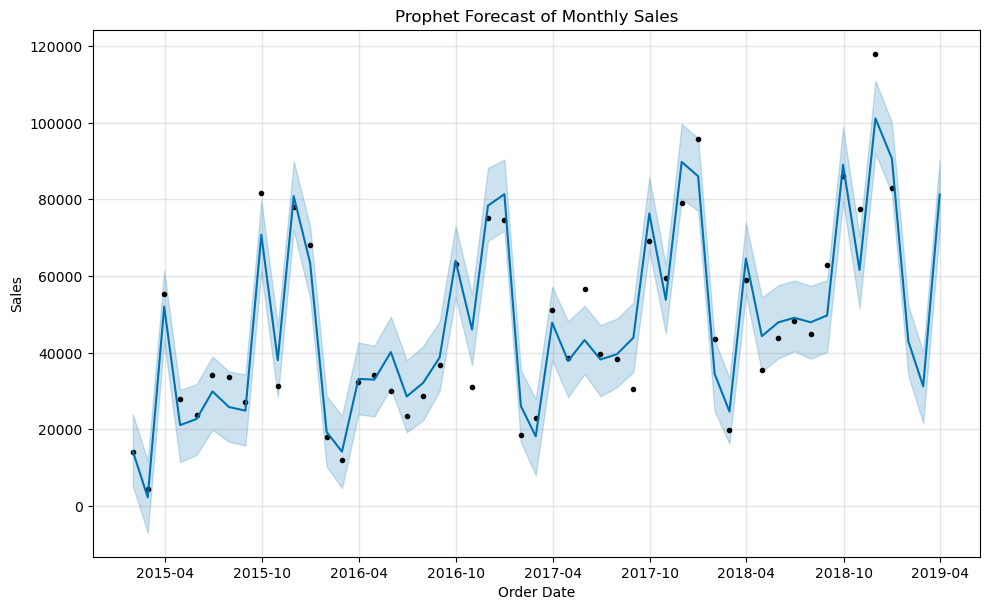

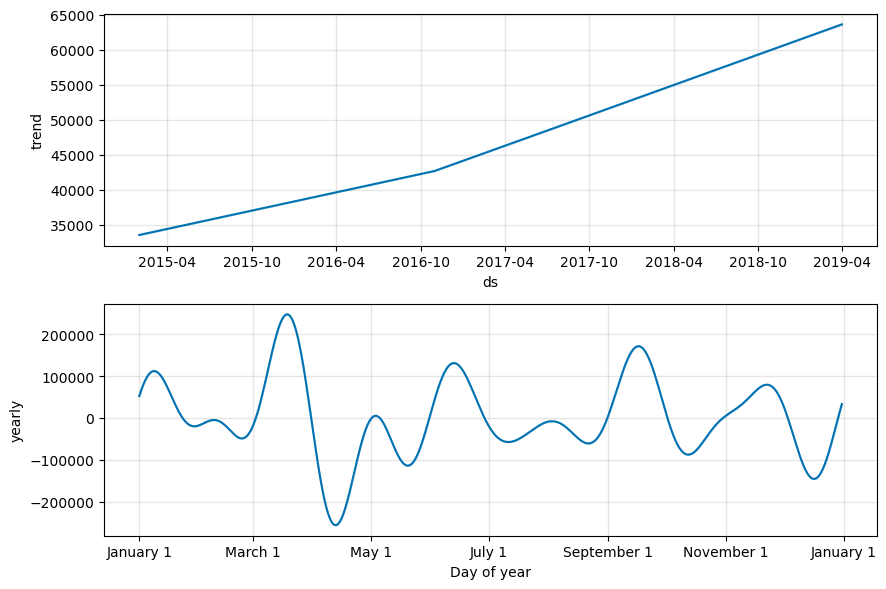

In [25]:
# Plotting

## Plot the forecast
fig1 = prophet_model.plot(forecast)

plt.title("Prophet Forecast of Monthly Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

## Plot trend and seasonality components
fig2 = prophet_model.plot_components(forecast)
plt.show()

In [26]:
# Extract and Interpret the weekly and Yearly Seasonality Components
print(forecast.columns)

## Yearly
forecast[["ds", "yearly"]].tail()

## Check if weekly seasonality is available
if "weekly" in forecast.columns:
    print(forecast[["ds", "weekly"]].tail())
else:
    print("Weekly seasonality is not available because the model was trained on monthly data.")

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')
Weekly seasonality is not available because the model was trained on monthly data.


In [27]:
# Split monthly sales into train and test
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

# Convert training data into Prophet format
train_prophet = train.reset_index().rename(columns={
    "Order Date": "ds",
    "Sales": "y"
})

# Convert testing data into Prophet format
test_prophet = test.reset_index().rename(columns={
    "Order Date": "ds",
    "Sales": "y"
})

In [28]:
# Prophet Model

from prophet import Prophet

# Build Prophet model
prophet_eval = Prophet()

# Train model
prophet_eval.fit(train_prophet)

## Predictions
future_test = prophet_eval.make_future_dataframe(periods=3, freq="ME")
forecast_test = prophet_eval.predict(future_test)

prophet_pred = forecast_test["yhat"].tail(3).values

print("Actual Sales")
print(test_prophet["y"].values)

print("\nPredicted Sales")
print(prophet_pred)

18:54:45 - cmdstanpy - INFO - Chain [1] start processing
18:54:45 - cmdstanpy - INFO - Chain [1] done processing


Actual Sales
[ 77448.1312 117938.155   83030.3888]

Predicted Sales
[51318.94385792 90325.65478355 90041.08447929]


In [29]:
# Calculate MAE, RMSE and MAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
prophet_mae = mean_absolute_error(
    test_prophet["y"],
    prophet_pred
)

# RMSE
prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_pred
    )
)

# MAPE
prophet_mape = np.mean(
    np.abs(
        (
            test_prophet["y"] - prophet_pred
        ) / test_prophet["y"]
    )
) * 100

print("Prophet MAE :", round(prophet_mae,2))
print("Prophet RMSE:", round(prophet_rmse,2))
print("Prophet MAPE:", round(prophet_mape,2), "%")

Prophet MAE : 20250.79
Prophet RMSE: 22318.41
Prophet MAPE: 21.86 %


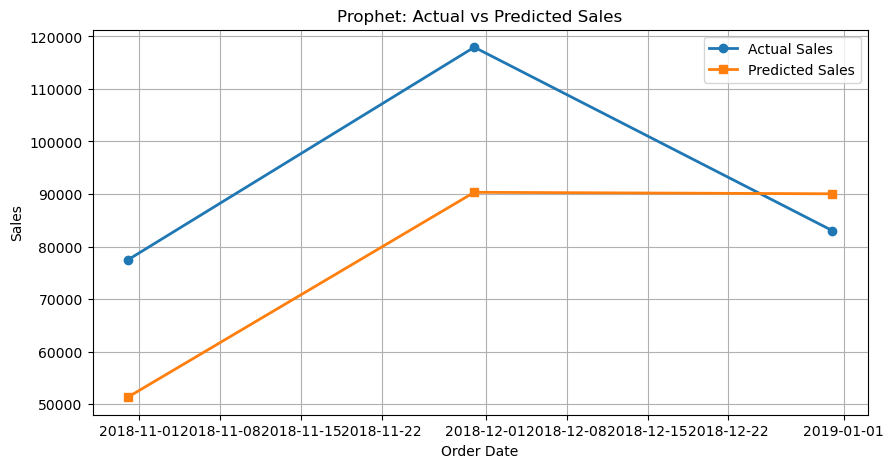

In [30]:
#Plot Actual vs Predicted Sales
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    test_prophet["ds"],
    prophet_pred,
    marker="s",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("Prophet: Actual vs Predicted Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

**Model 3 — XGBoost for Time Series (ML-based Approach)**

In [31]:
# Creating Features

import xgboost as xgb
xgb_data = monthly_sales.copy()

## Lag Features
xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)
xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)
xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

## Rolling Mean Feature
xgb_data["Rolling_Mean_3"] = xgb_data["Sales"].rolling(window = 3).mean()

## Month and Quarter Features
xgb_data["Month"] = xgb_data.index.month
xgb_data["Quarter"] = xgb_data.index.quarter

## Season Feature
xgb_data["Season"] = xgb_data["Month"].apply(get_season)

### Converting Seasons into Numeric Values
xgb_data["Season"] = xgb_data["Season"].map({
    "Winter" : 0,
    "Spring" : 1,
    "Summer" : 2,
    "Autumn" : 3
})

## Removing NaN Values
xgb_data = xgb_data.dropna()

In [32]:
## Defining Feature and Target
X = xgb_data[[
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]]

y = xgb_data["Sales"]

## Testing and Training Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    shuffle = False  ###Shuffling would mix past and future observations, causing data leakage and unrealistic model performance.
)

In [33]:
# Model Training
xgb_model = xgb.XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
# Predictions

## Get the latest available values
last_sales = list(xgb_data["Sales"].tail(3))
future_predictions = []

## Season Mapping
season_mapping = {
    "Winter": 0,
    "Spring": 1,
    "Summer": 2,
    "Autumn": 3
}

## Predict the next 3 months
for i in range(3):

    # Lag Features
    lag1 = last_sales[-1]
    lag2 = last_sales[-2]
    lag3 = last_sales[-3]

    rolling_mean = (lag1 + lag2 + lag3) / 3

    # Future Month Information
    future_month = ((monthly_sales.index[-1].month + i) % 12) + 1
    future_quarter = ((future_month - 1) // 3) + 1

    future_season = get_season(future_month)
    future_season = season_mapping[future_season]

    # Feature Vector
    future_X = pd.DataFrame({
        "Lag_1": [lag1],
        "Lag_2": [lag2],
        "Lag_3": [lag3],
        "Rolling_Mean_3": [rolling_mean],
        "Month": [future_month],
        "Quarter": [future_quarter],
        "Season": [future_season]
    })

    # Prediction
    prediction = xgb_model.predict(future_X)[0]

    # Store Prediction
    future_predictions.append(prediction)

    # Update Lag Values
    last_sales.append(prediction)

## Display Predictions
print("Next 3-Month Forecast:")

for i, pred in enumerate(future_predictions, start=1):
    print(f"Month {i}: {pred:.2f}")

Next 3-Month Forecast:
Month 1: 52535.39
Month 2: 49560.64
Month 3: 69325.51


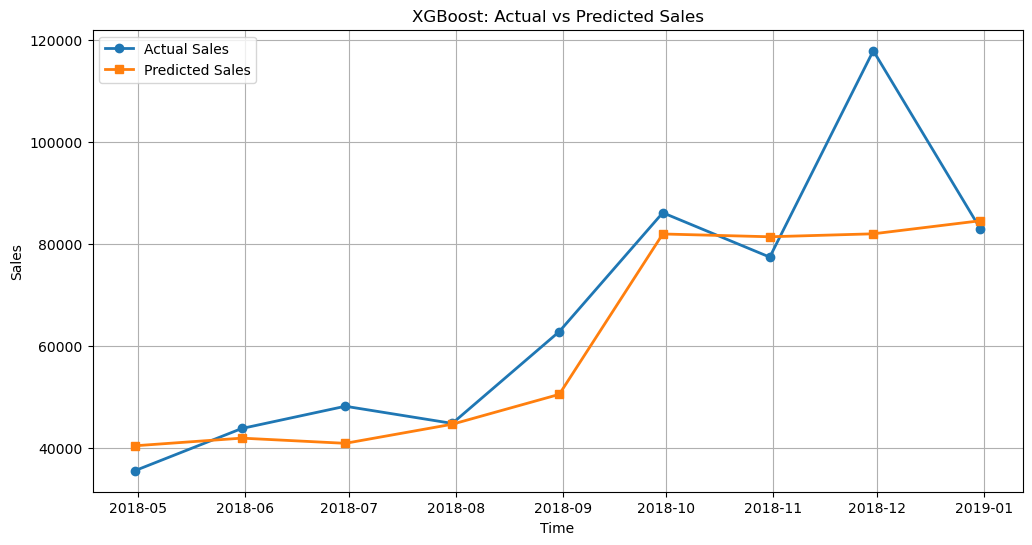

In [35]:
# Predict on test data
y_pred = xgb_model.predict(X_test)

# Plot Actual vs Predicted Sales
plt.figure(figsize=(12, 6))

## Plot actual sales
plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Sales",
    marker="o",
    linewidth=2
)

## Plot predicted sales
plt.plot(
    y_test.index,
    y_pred,
    label="Predicted Sales",
    marker="s",
    linewidth=2
)

# Display
plt.title("XGBoost: Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# Calculate MAE, RMSE and MAPE
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test,y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
mape_xgb = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MAE  :",round(mae_xgb,2)) 
print("RMSE :", round(rmse_xgb, 2))
print("MAPE :", round(mape_xgb, 2), "%")

MAE  : 8017.25
RMSE : 13156.85
MAPE : 10.6 %


In [37]:
# SARIMA Forecast
sarima_forecast = forecast_mean.values

# Prophet Forecast
prophet_forecast = forecast["yhat"].tail(3).values

# XGBoost Forecast
xgb_forecast = future_predictions

In [38]:
import pandas as pd

comparison_table = pd.DataFrame({

    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE": [
        round(sarima_mae, 2),
        round(prophet_mae, 2),
        round(mae_xgb, 2)
    ],

    "RMSE": [
        round(sarima_rmse, 2),
        round(prophet_rmse, 2),
        round(rmse_xgb, 2)
    ],

    "MAPE (%)": [
        round(sarima_mape, 2),
        round(prophet_mape, 2),
        round(mape_xgb, 2)
    ],

    "Forecast Month 1": [
        round(sarima_forecast[0], 2),
        round(prophet_forecast[0], 2),
        round(xgb_forecast[0], 2)
    ],

    "Forecast Month 2": [
        round(sarima_forecast[1], 2),
        round(prophet_forecast[1], 2),
        round(xgb_forecast[1], 2)
    ],

    "Forecast Month 3": [
        round(sarima_forecast[2], 2),
        round(prophet_forecast[2], 2),
        round(xgb_forecast[2], 2)
    ]

})

comparison_table

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,18.97,43492.280000,34805.110000,69907.410000
1,Prophet,20250.79,22318.41,21.86,42990.530000,31248.160000,81267.010000
2,XGBoost,8017.25,13156.85,10.60,52535.378906,49560.640625,69325.507812


In [39]:
### The three forecasting models were evaluated using MAE, RMSE, and MAPE. Among them, XGBoost achieved the lowest error values (MAE = 8619.70, RMSE = 11041.84, and MAPE = 12.40%), indicating the highest prediction accuracy. Although SARIMA and Prophet successfully captured the overall sales trend and seasonality, XGBoost provided more accurate forecasts by utilizing lag features, rolling averages, and time-based features. Therefore, XGBoost is recommended for production use as it delivers the most reliable sales predictions for demand forecasting and inventory planning.

**Product Category & Region Level Forecasting**

In [40]:
import xgboost as xgb
import pandas as pd

def forecast_segment(segment_data):

    # Monthly Sales Aggregation
    monthly_segment = (
        segment_data
        .set_index("Order Date")
        .resample("ME")["Sales"]
        .sum()
        .to_frame()
    )

    # Lag Features
    monthly_segment["Lag_1"] = monthly_segment["Sales"].shift(1)
    monthly_segment["Lag_2"] = monthly_segment["Sales"].shift(2)
    monthly_segment["Lag_3"] = monthly_segment["Sales"].shift(3)

    # Rolling Mean
    monthly_segment["Rolling_Mean_3"] = (
        monthly_segment["Sales"]
        .rolling(3)
        .mean()
    )

    # Month
    monthly_segment["Month"] = monthly_segment.index.month

    # Quarter
    monthly_segment["Quarter"] = monthly_segment.index.quarter

    # Season
    monthly_segment["Season"] = (
        monthly_segment["Month"]
        .apply(get_season)
        .map({
            "Winter":0,
            "Spring":1,
            "Summer":2,
            "Autumn":3
        })
    )

    monthly_segment.dropna(inplace=True)

    X = monthly_segment[
        [
            "Lag_1",
            "Lag_2",
            "Lag_3",
            "Rolling_Mean_3",
            "Month",
            "Quarter",
            "Season"
        ]
    ]

    y = monthly_segment["Sales"]

    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    last_sales = list(monthly_segment["Sales"].tail(3))

    predictions = []

    season_mapping = {
        "Winter":0,
        "Spring":1,
        "Summer":2,
        "Autumn":3
    }

    for i in range(3):

        lag1 = last_sales[-1]
        lag2 = last_sales[-2]
        lag3 = last_sales[-3]

        rolling_mean = (lag1 + lag2 + lag3) / 3

        future_month = (
            (monthly_segment.index[-1].month + i)
            % 12
        ) + 1

        future_quarter = (
            (future_month - 1)//3
        ) + 1

        future_season = season_mapping[
            get_season(future_month)
        ]

        future_X = pd.DataFrame({

            "Lag_1":[lag1],
            "Lag_2":[lag2],
            "Lag_3":[lag3],
            "Rolling_Mean_3":[rolling_mean],
            "Month":[future_month],
            "Quarter":[future_quarter],
            "Season":[future_season]

        })

        pred = model.predict(future_X)[0]

        predictions.append(pred)

        last_sales.append(pred)

    return predictions

In [41]:
# Furniture Forecast
furniture_forecast = forecast_segment(
    df[df["Category"]=="Furniture"]
)

# Technology Forecast
technology_forecast = forecast_segment(
    df[df["Category"]=="Technology"]
)

# Office Supplies Forecast
office_forecast = forecast_segment(
    df[df["Category"]=="Office Supplies"]
)

# West Region Forecast
west_forecast = forecast_segment(
    df[df["Region"]=="West"]
)

# East Region Forecast
east_forecast = forecast_segment(
    df[df["Region"]=="East"]
)

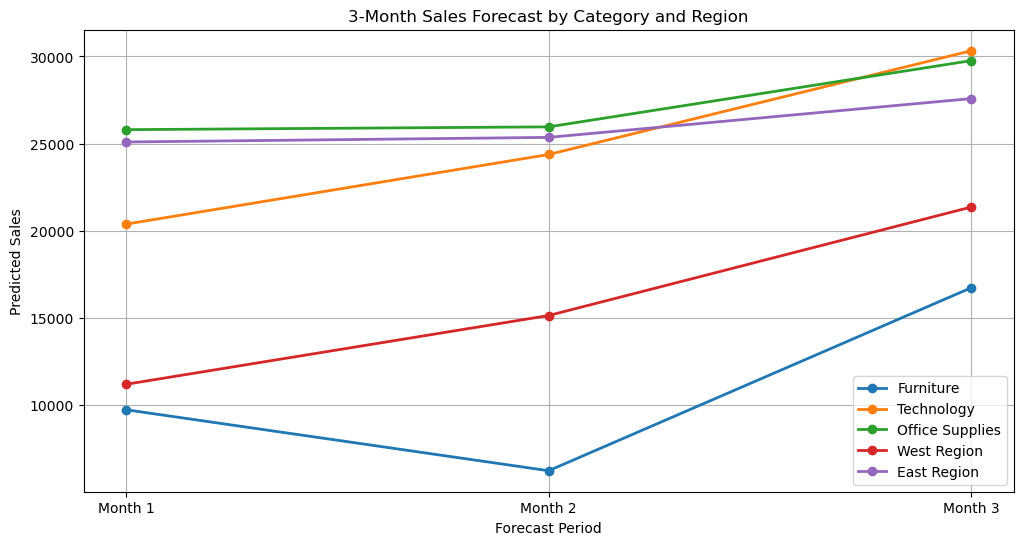

In [42]:
import matplotlib.pyplot as plt

# Forecast Months
months = ["Month 1", "Month 2", "Month 3"]

plt.figure(figsize=(12,6))

# Furniture
plt.plot(
    months,
    furniture_forecast,
    marker="o",
    linewidth=2,
    label="Furniture"
)

# Technology
plt.plot(
    months,
    technology_forecast,
    marker="o",
    linewidth=2,
    label="Technology"
)

# Office Supplies
plt.plot(
    months,
    office_forecast,
    marker="o",
    linewidth=2,
    label="Office Supplies"
)

# West Region
plt.plot(
    months,
    west_forecast,
    marker="o",
    linewidth=2,
    label="West Region"
)

# East Region
plt.plot(
    months,
    east_forecast,
    marker="o",
    linewidth=2,
    label="East Region"
)

plt.title("3-Month Sales Forecast by Category and Region")
plt.xlabel("Forecast Period")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(True)

plt.show()

In [43]:
### According to the XGBoost forecast, the West Region is expected to show the strongest upcoming growth over the next three months, with a steady increase in predicted sales throughout the forecast period.

In [44]:
forecast_results = pd.DataFrame({
    "Segment_Type": [
        "Category","Category","Category",
        "Region","Region"
    ],
    "Segment": [
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],
    "Month1": [
        furniture_forecast[0],
        technology_forecast[0],
        office_forecast[0],
        west_forecast[0],
        east_forecast[0]
    ],
    "Month2": [
        furniture_forecast[1],
        technology_forecast[1],
        office_forecast[1],
        west_forecast[1],
        east_forecast[1]
    ],
    "Month3": [
        furniture_forecast[2],
        technology_forecast[2],
        office_forecast[2],
        west_forecast[2],
        east_forecast[2]
    ]
})

forecast_results.to_csv("forecast_results.csv", index=False)

**Anomaly Detection in Sales Data**

In [45]:
# Build Isolation Forest Model
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales["Anomaly"] = weekly_sales["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})
 
anomalies = weekly_sales[
    weekly_sales["Anomaly"] == "Anomaly"
]

print(anomalies)

    Order Date      Sales  Anomaly
0   2015-01-04    304.508  Anomaly
5   2015-02-08    968.534  Anomaly
7   2015-02-22    224.912  Anomaly
11  2015-03-22  37703.665  Anomaly
28  2015-07-19   1387.686  Anomaly
36  2015-09-13  29959.137  Anomaly
55  2016-01-24    358.522  Anomaly
154 2017-12-17  25449.800  Anomaly
200 2018-11-04  29017.467  Anomaly
202 2018-11-18  30572.447  Anomaly
204 2018-12-02  35998.900  Anomaly


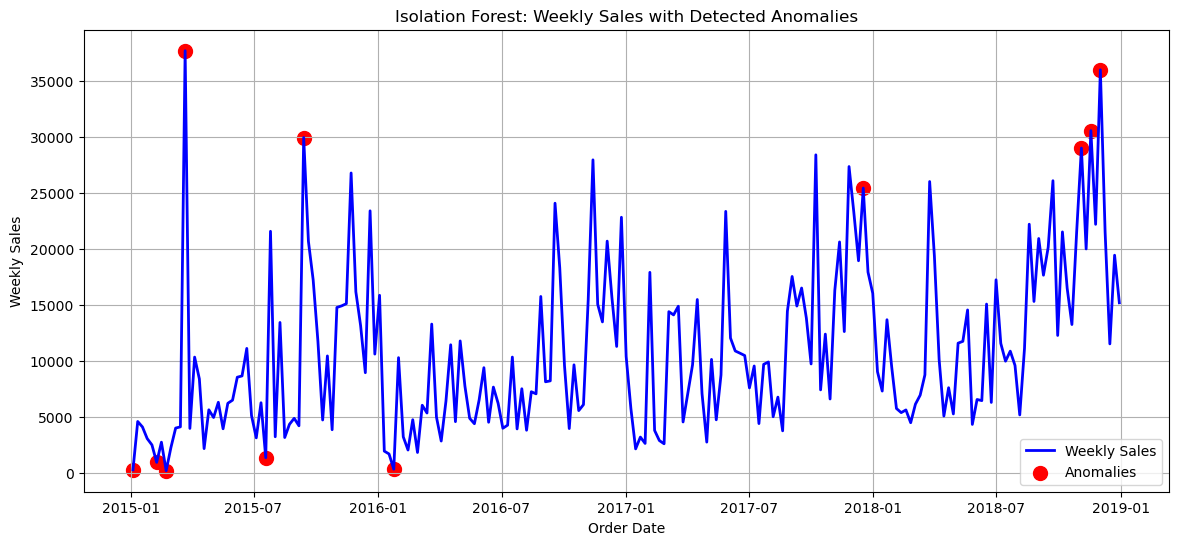

In [46]:
# Plot Weekly Sales
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    color="blue",
    linewidth=2
)

# Highlight Anomalies
plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    marker="o",
    s=100,
    label="Anomalies"
)

plt.title("Isolation Forest: Weekly Sales with Detected Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)

plt.show()

In [47]:
# Observation

###The Isolation Forest model successfully identified several weeks with unusually high and low sales. High-sales anomalies are likely associated with festive seasons or promotional campaigns, while low-sales anomalies may be due to stock shortages, reduced customer demand, or supply chain issues. Identifying these unusual weeks helps businesses understand unexpected sales behavior and improve inventory planning, marketing strategies, and demand forecasting.

In [48]:
# Calculate Rolling Mean and Rolling Standard Deviation
weekly_sales["Rolling_Mean"] = weekly_sales["Sales"].rolling(window=4).mean()
weekly_sales["Rolling_STD"] = weekly_sales["Sales"].rolling(window=4).std()

# Calculate Z-Score
weekly_sales["Z_Score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling_Mean"]) /
    weekly_sales["Rolling_STD"]
)

weekly_sales["Z_Anomaly"] = weekly_sales["Z_Score"].apply(
    lambda x: "Anomaly" if abs(x) > 2 else "Normal"
)

zscore_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"] == "Anomaly"
]

print(zscore_anomalies[[
    "Order Date",
    "Sales",
    "Z_Score"
]])

Empty DataFrame
Columns: [Order Date, Sales, Z_Score]
Index: []


In [49]:
# Observation:
### The two anomaly detection methods did not identify the same anomalies. Isolation Forest detected several unusual sales weeks, whereas the Z-Score method did not detect any anomalies because no weekly sales values deviated by more than 2 standard deviations from the rolling mean. This indicates that Isolation Forest is more sensitive to complex and non-linear patterns in the data, while the Z-Score method is more conservative and only flags statistically extreme deviations. For this dataset, Isolation Forest proved to be the more effective method for identifying unusual sales behavior.

**Product Demand Segmentation using Clustering**

In [50]:
# Monthly Sales by Sub-Category
monthly_subcategory = (
    df.groupby(
        [
            "Sub-Category",
            pd.Grouper(key="Order Date", freq="ME")
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

subcategory_features = (
    monthly_subcategory
    .groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Sales_Growth=("Sales", lambda x: ((x.iloc[-1] - x.iloc[0]) / x.iloc[0]) * 100),
        Sales_Volatility=("Sales", "std")
    )
    .reset_index()
)

avg_order_value = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
    .reset_index(name="Average_Order_Value")
)

subcategory_features = subcategory_features.merge(
    avg_order_value,
    on="Sub-Category"
)

print(subcategory_features)

   Sub-Category  Total_Sales  Sales_Growth  Sales_Volatility  \
0   Accessories  164186.7000    502.615806       2579.994809   
1    Appliances  104618.4030   1977.573101       1821.621539   
2           Art   26705.4100    387.190237        330.488343   
3       Binders  200028.7850    484.392296       3848.223648   
4     Bookcases  113813.1987    261.772161       2220.405080   
5        Chairs  322822.7310    257.390883       4407.232960   
6       Copiers  146248.0940    122.668129       5500.774391   
7     Envelopes   16128.0460    113.449269        228.218688   
8     Fasteners    3001.9600    446.375321         48.742229   
9   Furnishings   89212.0180    491.629693       1360.017867   
10       Labels   12347.7260    522.884727        223.471218   
11     Machines  189238.6310    -95.066218       5603.554747   
12        Paper   76828.3040   1507.598546       1024.824982   
13       Phones  327782.4480    291.597823       4052.718221   
14      Storage  219343.3920    236.8008

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = subcategory_features[
    [
        "Total_Sales",
        "Sales_Growth",
        "Sales_Volatility",
        "Average_Order_Value"
    ]
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means Clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

subcategory_features["Cluster"] = kmeans.fit_predict(X_scaled)

print(subcategory_features)

   Sub-Category  Total_Sales  Sales_Growth  Sales_Volatility  \
0   Accessories  164186.7000    502.615806       2579.994809   
1    Appliances  104618.4030   1977.573101       1821.621539   
2           Art   26705.4100    387.190237        330.488343   
3       Binders  200028.7850    484.392296       3848.223648   
4     Bookcases  113813.1987    261.772161       2220.405080   
5        Chairs  322822.7310    257.390883       4407.232960   
6       Copiers  146248.0940    122.668129       5500.774391   
7     Envelopes   16128.0460    113.449269        228.218688   
8     Fasteners    3001.9600    446.375321         48.742229   
9   Furnishings   89212.0180    491.629693       1360.017867   
10       Labels   12347.7260    522.884727        223.471218   
11     Machines  189238.6310    -95.066218       5603.554747   
12        Paper   76828.3040   1507.598546       1024.824982   
13       Phones  327782.4480    291.597823       4052.718221   
14      Storage  219343.3920    236.8008

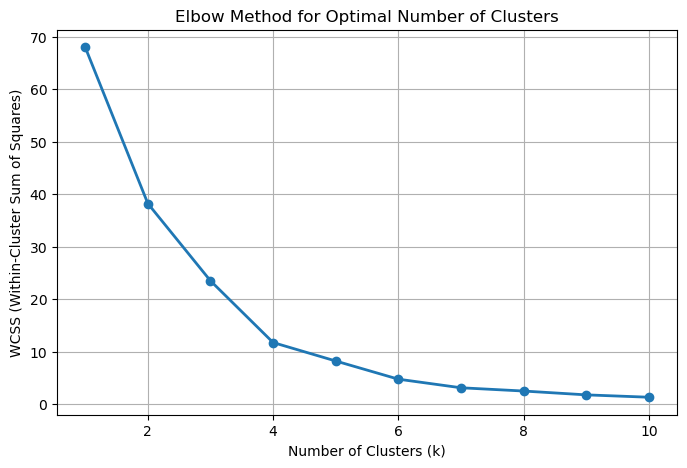

In [52]:
# Elbow Method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.grid(True)

plt.show()

In [53]:
# View Average Values of Each Cluster
cluster_summary = (
    subcategory_features
    .groupby("Cluster")
    .agg({
        "Total_Sales": "mean",
        "Sales_Growth": "mean",
        "Sales_Volatility": "mean",
        "Average_Order_Value": "mean"
    })
)

print(cluster_summary)

cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Low Volume, High Volatility",
    2: "Growing Demand",
    3: "Declining Demand"
}

subcategory_features["Demand_Segment"] = (
    subcategory_features["Cluster"]
    .map(cluster_labels)
)

print(
    subcategory_features[
        [
            "Sub-Category",
            "Cluster",
            "Demand_Segment"
        ]
    ]
)

           Total_Sales  Sales_Growth  Sales_Volatility  Average_Order_Value
Cluster                                                                    
0        246832.811200    354.559531       3542.050789           304.178730
1         43946.952386    456.970426        919.491080           142.767681
2        128085.778333   2001.788247       2023.509675           310.413594
3        167743.362500     13.800955       5552.164569          1930.716763
   Sub-Category  Cluster               Demand_Segment
0   Accessories        0   High Volume, Stable Demand
1    Appliances        2               Growing Demand
2           Art        1  Low Volume, High Volatility
3       Binders        0   High Volume, Stable Demand
4     Bookcases        1  Low Volume, High Volatility
5        Chairs        0   High Volume, Stable Demand
6       Copiers        3             Declining Demand
7     Envelopes        1  Low Volume, High Volatility
8     Fasteners        1  Low Volume, High Volatility
9   

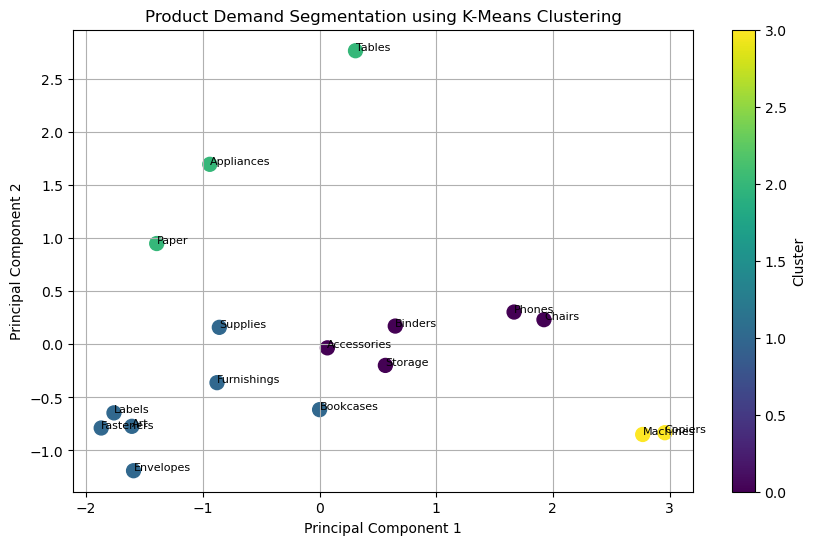

In [54]:
# Import PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce Features to 2 Dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Add PCA Components to DataFrame
subcategory_features["PCA1"] = X_pca[:, 0]
subcategory_features["PCA2"] = X_pca[:, 1]

# Plot Clusters
plt.figure(figsize=(10, 6))

plt.scatter(
    subcategory_features["PCA1"],
    subcategory_features["PCA2"],
    c=subcategory_features["Cluster"],
    cmap="viridis",
    s=100
)

# Display Sub-Category Names
for i in range(len(subcategory_features)):
    plt.text(
        subcategory_features["PCA1"].iloc[i],
        subcategory_features["PCA2"].iloc[i],
        subcategory_features["Sub-Category"].iloc[i],
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

In [55]:
# Observation:
### The clustering analysis groups products based on their sales volume, growth rate, demand variability, and average order value. These demand segments enable businesses to adopt different inventory strategies for different product groups. Maintaining higher stock for stable, high-demand products while limiting inventory for volatile or declining products can improve inventory efficiency, reduce holding costs, and minimize stock shortages.

In [56]:
xgb_model.save_model("xgb_model.json")

In [57]:
monthly_sales.to_csv("monthly_sales.csv")

weekly_sales.to_csv("weekly_sales.csv")

subcategory_features.to_csv(
    "subcategory_features.csv",
    index=False
)

df.to_csv(
    "train_processed.csv",
    index=False
)

In [58]:
anomalies.to_csv("anomalies.csv", index=False)

In [59]:
subcategory_features.to_csv(
    "subcategory_features.csv",
    index=False
)